# Laboratorio 8 - Deep Learning

- Juan Solís - 23720
- Victor Pérez - 23731
- Diego Flores - 23714

## Implementación Mini GPT Semana 6

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, urllib.request
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Mini-GPT de la Semana 6 (adaptado a batches y a n_layers bloques)
def layer_norm(x, gamma, beta, eps=1e-5):
    # LN(x) = gamma * (x - media) / (std + eps) + beta
    mean = x.mean(dim=-1, keepdim=True)
    std = x.std(dim=-1, keepdim=True, unbiased=False)

    return gamma * (x - mean) / (std + eps) + beta

def make_positional_encoding(max_len, d_model):
    # PE(t, 2i) = sin(t / 10000^(2i/d_model)),  PE(t, 2i+1) = cos(t / 10000^(2i/d_model))
    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(max_len).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)

    return pe

# Bloque decoder: masked self-attention -> Add & Norm -> FFN -> Add & Norm
class GPTBlock(nn.Module):
    def __init__(self, d_model, d_ff, n_heads):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.WQ = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WK = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WV = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WO = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1 = nn.Parameter(torch.zeros(d_model))
        self.W1 = nn.Parameter(torch.randn(d_model, d_ff) * 0.1)
        self.b1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.randn(d_ff, d_model) * 0.1)
        self.b2 = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2 = nn.Parameter(torch.zeros(d_model))

    def masked_self_attention(self, x, causal):
        B, T, _ = x.shape
        Q = (x @ self.WQ).view(B, T, self.n_heads, self.d_k).transpose(1, 2) # (B, H, T, d_k)
        K = (x @ self.WK).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = (x @ self.WV).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        scores = Q @ K.transpose(-1, -2) / math.sqrt(self.d_k) # QK^T / sqrt(d_k)
        scores = scores.masked_fill(causal[:T, :T], float('-inf')) # mascara causal
        attn_w = F.softmax(scores, dim=-1)
        out = (attn_w @ V).transpose(1, 2).contiguous().view(B, T, self.d_model)

        return out @ self.WO

    def feed_forward(self, x):
        # FFN(x) = ReLU(x W1 + b1) W2 + b2
        return F.relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

    def forward(self, x, causal):
        x2 = layer_norm(x + self.masked_self_attention(x, causal), self.gamma1, self.beta1)
        return layer_norm(x2 + self.feed_forward(x2), self.gamma2, self.beta2)

# Transformer decoder-only: E[idxs] + PE -> n_layers bloques -> proyeccion al vocabulario
class MiniGPT(nn.Module):
    def __init__(self, V, d_model, d_ff, n_heads, n_layers, block_size):
        super().__init__()
        self.E = nn.Parameter(torch.randn(V, d_model))  # std 1 (como nn.Embedding) para que la PE no opaque al token
        self.blocks = nn.ModuleList([GPTBlock(d_model, d_ff, n_heads) for _ in range(n_layers)])
        self.Wlm = nn.Parameter(torch.randn(d_model, V) * 0.1)
        self.blm = nn.Parameter(torch.zeros(V))
        self.register_buffer('pe', make_positional_encoding(block_size, d_model))
        self.register_buffer('causal', torch.triu(torch.ones(block_size, block_size), diagonal=1).bool())

    def forward(self, idxs):
        # idxs: (B, T) -> logits: (B, T, V)
        T = idxs.shape[1]
        x = self.E[idxs] + self.pe[:T]
        
        for block in self.blocks:
            x = block(x, self.causal)
        return x @ self.Wlm + self.blm

## Task 1

### Task 1.1

Se descarga `tiny_shakespeare`, se construye el vocabulario de caracteres con sus mappings carácter-índice y se codifica el texto, dividiéndolo en 90% entrenamiento y 10% validación sin alterar el orden. También se define la función `get_batch`, que genera secuencias de longitud `block_size` cuyo objetivo es la misma secuencia desplazada un paso hacia el futuro.

In [2]:
# Hiperparametros
block_size = 128
d_model= 128
n_heads = 4
n_layers = 3
batch_size = 64
lr = 3e-4
epochs = 10
d_ff = 4 * d_model

# Descarga del dataset
url='https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
urllib.request.urlretrieve( url, 'input.txt')
with open('input.txt', encoding='utf-8' ) as f:
    text = f.read()

# Vocabulario y mappings bidireccionales caracter indice
chars = sorted(set(text) )
V = len(chars )
stoi = { c: i for i, c in enumerate(chars)}
itos = { i: c for c, i in stoi.items()}
print(f'Tamano del vocabulario: {V}' )

# Codificacion del texto y division 90/10 respetando el orden
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f'Train: {len(train_data)} tokens | Val: {len(val_data)} tokens')

# Batches: y es x desplazada un paso hacia el futuro
def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print(f'x: {tuple(xb.shape)} | y: {tuple(yb.shape)}')

Tamano del vocabulario: 65
Train: 1003854 tokens | Val: 111540 tokens


x: (64, 128) | y: (64, 128)


### Task 1.2

Se entrena el Mini-GPT sobre `tiny_shakespeare` con los hiperparámetros anteriores, registrando la pérdida de entrenamiento y validación en cada época para graficar sus curvas. Al final se calcula la perplejidad de validación como la exponencial de la cross-entropy promedio sobre todos los tokens del conjunto de validación.

Epoch  1: train_loss=2.9290 | val_loss=2.5621


Epoch  2: train_loss=2.4927 | val_loss=2.4533


Epoch  3: train_loss=2.3827 | val_loss=2.3478


Epoch  4: train_loss=2.2666 | val_loss=2.2423


Epoch  5: train_loss=2.1661 | val_loss=2.1681


Epoch  6: train_loss=2.0802 | val_loss=2.1117


Epoch  7: train_loss=2.0158 | val_loss=2.0664


Epoch  8: train_loss=1.9555 | val_loss=2.0308


Epoch  9: train_loss=1.9067 | val_loss=2.0035


Epoch 10: train_loss=1.8670 | val_loss=1.9644


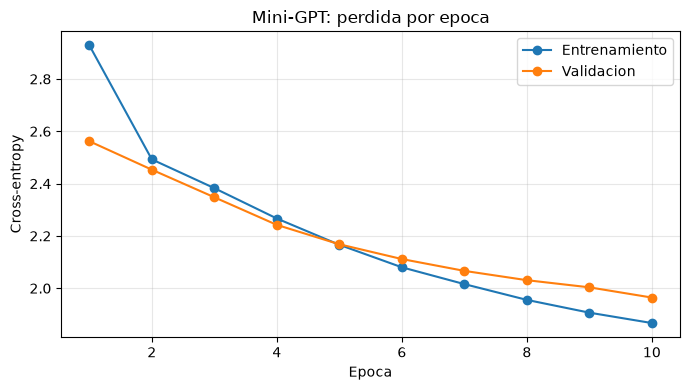

Perplejidad de validacion: 7.1307


In [3]:
model = MiniGPT(V, d_model, d_ff, n_heads, n_layers, block_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
steps_per_epoch = len(train_data) // (batch_size * block_size)  # ~una pasada por el set de entrenamiento

@torch.no_grad()
def evaluate(d):
    # Cross-entropy promedio (1/N) * sum L_t sobre todos los tokens de d
    n_blocks = (len(d) - 1) // block_size
    x = d[:n_blocks * block_size].view(n_blocks, block_size)
    y = d[1:n_blocks * block_size + 1].view(n_blocks, block_size)
    total, N = 0.0, 0
    for i in range(0, n_blocks, batch_size):
        xb, yb = x[i:i + batch_size].to(device), y[i:i + batch_size].to(device)
        logits = model(xb)
        total += F.cross_entropy(logits.view(-1, V), yb.view(-1), reduction='sum').item()
        N += yb.numel()
    return total / N

# Entrenamiento
train_losses, val_losses = [], []
for epoch in range(epochs):
    total = 0.0
    for _ in range(steps_per_epoch):
        xb, yb = get_batch('train')
        logits = model(xb)
        loss = F.cross_entropy(logits.view(-1, V), yb.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    train_losses.append(total / steps_per_epoch)
    val_losses.append(evaluate(val_data))
    print(f'Epoch {epoch + 1:2d}: train_loss={train_losses[-1]:.4f} | val_loss={val_losses[-1]:.4f}')

# Curvas de perdida por epoca
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_losses, 'o-', label='Entrenamiento')
plt.plot(range(1, epochs + 1), val_losses, 'o-', label='Validacion')
plt.title('Mini-GPT: perdida por epoca'); plt.xlabel('Epoca'); plt.ylabel('Cross-entropy')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# Perplejidad de validacion = exp((1/N) * sum L_t)
val_ppl = math.exp(val_losses[-1])
print(f'Perplejidad de validacion: {val_ppl:.4f}')

### Task 1.3

Se implementan desde cero las tres estrategias de muestreo (greedy, top-k con temperatura y top-p con temperatura), cada una recibe los logits crudos del modelo y retorna el índice del siguiente token.

In [4]:
# Muestreo greedy: argmax de los logits, sin aleatoriedad
def greedy_sampling(logits):
    return torch.argmax(logits).item()

# Muestreo top-k con temperatura
def top_k_sampling(logits, k, tau):
    logits = logits / tau # z / tau
    vals, idxs = torch.topk(logits, k) # k logits mas altos
    filtered = torch.full_like(logits, float('-inf')) # -inf al resto
    filtered[idxs] = vals
    probs = F.softmax(filtered, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()

# Muestreo top-p (nucleus) con temperatura
def top_p_sampling(logits, p, tau):
    probs = F.softmax(logits / tau, dim=-1) # softmax(z / tau)
    sorted_probs, sorted_idxs = torch.sort(probs, descending=True)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    keep = (cum_probs - sorted_probs) < p # tokens hasta superar p
    kept_probs = sorted_probs[keep] / sorted_probs[keep].sum() # renormalizar
    choice = torch.multinomial(kept_probs, num_samples=1).item()
    return sorted_idxs[keep][choice].item()

## Task 2

### Task 2.1

Se implementa `generate`, que codifica el prompt y en cada paso pasa al modelo los últimos `block_size` caracteres, toma los logits de la última posición y elige el siguiente carácter con la estrategia indicada. Se generan 5 muestras de 200 caracteres por configuración partiendo de `"ROMEO:"`.

In [5]:
samplers = {'greedy': greedy_sampling, 'top_k': top_k_sampling, 'top_p': top_p_sampling}

@torch.no_grad()
def generate(prompt, max_new_tokens, strategy, **kwargs):
    model.eval()
    idxs = torch.tensor([[stoi[c] for c in prompt]], device=device)
    for _ in range(max_new_tokens):
        logits = model(idxs[:, -block_size:])[0, -1] # solo cabe block_size de contexto por la PE
        nxt = samplers[strategy](logits, **kwargs)
        idxs = torch.cat([idxs, torch.tensor([[nxt]], device=device)], dim=1)
    return ''.join(itos[i] for i in idxs[0].tolist())

configs = {
    'A': ('greedy', {}),
    'B': ('top_k', {'k': 5, 'tau': 0.7}),
    'C': ('top_k', {'k': 50, 'tau': 1.0}),
    'D': ('top_p', {'p': 0.70, 'tau': 0.7}),
    'E': ('top_p', {'p': 0.95, 'tau': 1.0}),
}

torch.manual_seed(0)
samples = {}
for name, (strategy, kwargs) in configs.items():
    samples[name] = [generate('ROMEO:', 200, strategy, **kwargs) for _ in range(5)]
    print(f'{"=" * 25} Configuracion {name}: {strategy} {kwargs} {"=" * 25}')
    for i, s in enumerate(samples[name], 1):
        print(f'--- Muestra {i} ---\n{s}\n')


========================= Configuracion A: greedy {} =========================
--- Muestra 1 ---
ROMEO:
The shall the the stake the the sore the the son the the stand the the so the the so the seee the seeed
That the so the seee the shall be the seee to the seee the shall be the seee to the seee the sh

--- Muestra 2 ---
ROMEO:
The shall the the stake the the sore the the son the the stand the the so the the so the seee the seeed
That the so the seee the shall be the seee to the seee the shall be the seee to the seee the sh

--- Muestra 3 ---
ROMEO:
The shall the the stake the the sore the the son the the stand the the so the the so the seee the seeed
That the so the seee the shall be the seee to the seee the shall be the seee to the seee the sh

--- Muestra 4 ---
ROMEO:
The shall the the stake the the sore the the son the the stand the the so the the so the seee the seeed
That the so the seee the shall be the seee to the seee the shall be the seee to the seee the sh

--- Muestra 5 ---

========================= Configuracion B: top_k {'k': 5, 'tau': 0.7} =========================
--- Muestra 1 ---
ROMEO:
Thy this the hen the head heaven and thee streed houre sond haver
That the him be have sone him stante of we wake have of thath,
Ar see met to so seen ston but
Whe seeet to the wo this wenther the wa

--- Muestra 2 ---
ROMEO:
The what his till bood the she to thou be their himse the to to she
Theing to the art the staid that here to both but a the that
the conosus but but brace. The teembe such bof well to state he that s

--- Muestra 3 ---
ROMEO:
I will the how here the his him a he a hat well ast to the
To he think seeat have our the was and the so stake thou have bee this the the wene this the to deather thee bothere and to mader.

Flet Sen

--- Muestra 4 ---
ROMEO:
I tis seal, is a a thim are
and so so to the hear some, and and the armone.

PEOMENEN:
O see thee hir signg or the a the bush be som ande this should and.

COMISTHAS:
Nay, then but the the besing the



========================= Configuracion C: top_k {'k': 50, 'tau': 1.0} =========================
--- Muestra 1 ---
ROMEO:
I tas dad sucht, I am a aure a now'ld Abe the;
As up cayoun me yout compst! for but dith holave,
And infor inguighs my handom.

Glame, the parsoow a by by ing.


AGRICK:
Ah:
Latu:
O mustcsett, my my 

--- Muestra 2 ---
ROMEO:
Thy my live: did not me;
And sugee trpen clusiod, she and: pacee: as wenk,
Esave you
how shonousse shes, deper.

KIXESABELO:
Bet, they gongue, seye bruch.

Vid for Rubetess?

UMENENUc:
Hevee lett bea

--- Muestra 3 ---
ROMEO:
Fhe cancce and the to these prace that cupin.
And the's with like it.

NER:
So I Game comie: of tembse hean
And this dake of I lamet,
Or the poisinjota.


BELINIO:
By'll will, fonccle, itSe? ast the 

--- Muestra 4 ---
ROMEO:
in this tray for twevers my bexy light hoth moughtard,
Sealy all enbminat: thou a wit the par
Te shal eeadousme:
To whes, par kee eprcub'd theer:
It day ret pram; have fow: pown hat.

HEN ERCHANNT:
N


========================= Configuracion D: top_p {'p': 0.7, 'tau': 0.7} =========================
--- Muestra 1 ---
ROMEO:
That the have the with spain it.

HARINARD:
How moth the my seend the on the the here,
I the she all of fries of a the father oncences to heave in thim.

CORIOLANUS:
No, my lad the doner heave surs b

--- Muestra 2 ---
ROMEO:
Ay, that the the doner son and bear that ben may my sould.

HENRY VINCENTIO:
What my and and the the seelf it here,
And heave mare for the beares manty then but a so but me at strean.
The moser, wher

--- Muestra 3 ---
ROMEO:
I swell have well the of the the his the sould and the beat of with count me,
The he seee of the me man for a the make,
And the seee here heave seears of the a the sead.

So MERIO:
The we art bearth 

--- Muestra 4 ---
ROMEO:
What her searse hat son a shere praty to the a so sto with the shall of brotherer the hereave
When me for be of the the but heaver to be the thee ther stan beat the the hather heave of the at the the

========================= Configuracion E: top_p {'p': 0.95, 'tau': 1.0} =========================
--- Muestra 1 ---
ROMEO:
I some' you sould comes.

GLOUCES MONE:
Me midens, be Thath apile in peryithes the old heave
All say for to shink have
Tilttis the you, to be it
thee a shalal stingser, delasss, rige:
My naight blay 

--- Muestra 2 ---
ROMEO:
Nome, haves letss onf and mest,
Fror, I make him I out to poees: 'tit, hank and.
Heshe fllam a undous this and you, but forseles.
What aros I now him
Art stee, I seteemil: you thour he cumyst:
I'll t

--- Muestra 3 ---
ROMEO:
For I him for now tight.

CORINIUS:
Yet:
Let weres yetal they how wof sair thou do the thank be foold.
Abuse he then givous a thankes!
Paret lates becarious cones a ther.
Freast there seends: thy I w

--- Muestra 4 ---
ROMEO:
Olld alow preming. Thy with wepeces man mery her?
Is sarem force the, go meak? this should
I'll the me year, for agalt the dranty;
Shath, not spen, takew my or my cown other love,
the the chanall to

Como apoyo para la Task 2.2, se mide cuántos candidatos conserva top-p (p=0.95, tau=1.0) en cada paso de las muestras de E: un núcleo pequeño indica que el modelo está seguro del siguiente carácter y uno grande que está inseguro.

In [6]:
# Tamano del nucleo (p=0.95, tau=1.0) en cada paso de las muestras de E
@torch.no_grad()
def nucleus_sizes(text, p=0.95, tau=1.0):
    idxs = torch.tensor([stoi[c] for c in text], device=device)
    sizes = []
    for t in range(len('ROMEO:'), len(text)):
        probs = F.softmax(model(idxs[None, max(0, t - block_size):t])[0, -1] / tau, dim=-1)
        sorted_probs = torch.sort(probs, descending=True).values
        sizes.append(((sorted_probs.cumsum(-1) - sorted_probs) < p).sum().item())
    return sizes

def context_type(prev):
    if prev == ' ': return 'tras espacio'
    if prev == '\n': return 'tras salto de linea'
    if prev.isalpha(): return 'dentro de palabra'
    return 'tras puntuacion'

by_type, steps = {}, []
for i, s in enumerate(samples['E'], 1):
    for t, size in enumerate(nucleus_sizes(s), len('ROMEO:')):
        by_type.setdefault(context_type(s[t - 1]), []).append(size)
        steps.append((size, i, s[max(0, t - 15):t], s[t]))

print('Tamano promedio del nucleo segun el caracter previo:')
for k, v in sorted(by_type.items(), key=lambda kv: sum(kv[1]) / len(kv[1])):
    print(f'  {k:20s} {sum(v) / len(v):5.1f} candidatos  ({len(v)} pasos)')

steps.sort(key=lambda x: x[0])
for title, rows in [('Pasos mas seguros', steps[:8]), ('Pasos mas inseguros', steps[-8:])]:
    print(f'\n{title}:')
    for size, i, ctx, ch in rows:
        print(f'  muestra {i} | {size:2d} candidatos | {ctx!r} -> {ch!r}')


Tamano promedio del nucleo segun el caracter previo:
  tras puntuacion        2.3 candidatos  (53 pasos)
  dentro de palabra     10.0 candidatos  (750 pasos)
  tras salto de linea   21.8 candidatos  (34 pasos)
  tras espacio          21.9 candidatos  (163 pasos)

Pasos mas seguros:
  muestra 1 |  1 candidatos | 'ROMEO:' -> '\n'
  muestra 1 |  1 candidatos | "MEO:\nI some' yo" -> 'u'
  muestra 1 |  1 candidatos | '\n\nGLOUCES MONE:' -> '\n'
  muestra 1 |  1 candidatos | 'ONE:\nMe midens,' -> ' '
  muestra 1 |  1 candidatos | '\nTilttis the yo' -> 'u'
  muestra 1 |  1 candidatos | 'ilttis the you,' -> ' '
  muestra 1 |  1 candidatos | 'lasss, rige:\nMy' -> ' '
  muestra 2 |  1 candidatos | 'ROMEO:' -> '\n'

Pasos mas inseguros:
  muestra 4 | 32 candidatos | ' the, go meak? ' -> 't'
  muestra 1 | 33 candidatos | ' to shink have\n' -> 'T'
  muestra 4 | 33 candidatos | 'w preming. Thy ' -> 'w'
  muestra 5 | 33 candidatos | 'aks grove.\nThe ' -> 'M'
  muestra 5 | 33 candidatos | 'ch, be ther

### Task 2.2

**a) Configuración A (greedy)**

El muestreo greedy elige en cada paso $w_t = \arg\max_i P(w_i \mid \text{ctx})$. Esto tiene dos consecuencias que se ven en las muestras:

- **Es determinista**: el siguiente carácter es una función fija del contexto, por lo que las 5 muestras de A son idénticas carácter por carácter. No hay forma de obtener variedad sin cambiar el prompt.
- **Ignora toda la masa de probabilidad fuera de la moda**: el modelo tiene una perplejidad de validación de ~7.1, es decir, la distribución del siguiente carácter suele repartirse entre varios candidatos. Aunque `t` tras un espacio tenga, por ejemplo, $P=0.3$ y el 0.7 restante esté repartido entre muchas otras letras, greedy siempre toma `t`, y luego `h`, `e` y espacio, porque " the " es el patrón más frecuente del corpus. Por eso la muestra está dominada por "the" y por la `e` repetida *"seee"*, *"seeed"*.

Los ciclos aparecen porque, como la decisión depende solo del contexto, en cuanto la ventana de entrada contiene una frase repetida el modelo vuelve a producir la misma continuación, y la atención refuerza aún más ese patrón. Al final de la muestra el texto entra en un ciclo de periodo fijo: *"the seee the shall be the seee to the seee the shall be the seee to the seee..."*. Greedy maximiza la probabilidad de cada carácter por separado, no la de la secuencia, y eso lleva a quedarse en esa zona de alta probabilidad local.

**b) Configuraciones B (k=5, τ=0.7) vs C (k=50, τ=1.0)**

- **Efecto de k**: top-k pone en $-\infty$ todos los logits salvo los $k$ más altos antes del softmax. Con $|V| = 65$, $k=5$ deja solo las 5 letras más probables, mientras que $k=50$ casi no recorta nada (conserva ~77% del vocabulario). Al subir $k$ entran caracteres de baja probabilidad, y eso aumenta la diversidad pero también el ruido.
- **Efecto de τ**: el cociente entre dos probabilidades es $\frac{P(w_i)}{P(w_j)} = \exp\left(\frac{z_i - z_j}{\tau}\right)$. Con $\tau=0.7$ las diferencias entre logits se multiplican por $1/0.7 \approx 1.43$, así que la distribución se concentra más en los candidatos dominantes. Con $\tau=1.0$ se usa la distribución original del modelo, que es más plana. Pasar de 0.7 a 1.0 reduce la concentración y le da más peso a la cola.

En las muestras:

- **B es la más coherente**: casi todas sus palabras existen o se parecen al inglés (*"Think such a he bread too be him there."*, *"And me be hadred were him shall sheer."*) y respeta bien el formato de la obra, con nombres en mayúsculas seguidos de `:` y salto de línea (*"COMISTHAS:\nNay, then but..."*). A cambio repite palabras frecuentes, igual que greedy pero menos (*"the the"*, *"and and"*, *"but but"*, *"a a"*), porque solo puede elegir entre unas pocas letras muy probables.
- **C es la más creativa**: usa un vocabulario mucho más variado y sin repeticiones, pero inventa muchas palabras (*"trpen clusiod"*, *"eprcub'd"*, *"poisinjota"*, *"byeey"*) y mete caracteres poco probables donde no van (*"itSe?"*, *"UMENENUc:"*, *"KIXESABELO:"*). Esos son justamente los caracteres de la cola que B recorta.

**c) Configuración E (top-p=0.95, τ=1.0)**

Para identificar estos momentos se midió el tamaño del núcleo (cuántos caracteres hacen falta para acumular 0.95 de probabilidad) en cada paso de las 5 muestras de E. El promedio pasa de 2.3 candidatos tras un signo de puntuación a 10.0 dentro de una palabra y a ~22 tras un espacio o un salto de línea.

**Momentos de alta seguridad** (núcleo de 1 candidato):
- Tras el nombre de un personaje y `:`, el modelo está seguro de que sigue `\n`. Pasa con `ROMEO:` en todas las muestras y con *"GLOUCES MONE:"* en la muestra 1.
- Al completar palabras cuyo final ya está determinado, como `yo` -> `u` en *"I some' you"* y *"Tilttis the you"* (muestra 1).
- Tras una coma, como en *"Me midens,"* o *"the you,"* (muestra 1), siempre sigue un espacio.

Estos casos son de formato y ortografía y el corpus casi no tiene variación en ellos, así que la distribución queda casi en un solo carácter.

**Momentos de alta inseguridad** (núcleo de 32 a 35 candidatos):
- Al empezar una palabra nueva tras un espacio, como en *"Thy "* -> `w` (muestra 4), *"go meak? "* -> `t` (muestra 4) o *"Freast "* -> `t` (muestra 3).
- Al empezar un verso nuevo tras un salto de línea, como en *"to shink have\n"* -> `T` y *"the old heave\n"* -> `A` (muestra 1), o *"grove.\nThe "* -> `M` (muestra 5).

Aquí la decisión es semántica pensando qué palabra o verso viene después. Un modelo a nivel de carácter con este nivel de pérdida tiene muchas continuaciones plausibles, así que top-p conserva casi la mitad del vocabulario. Esto muestra el carácter adaptativo de E con el núcleo se reduce a 1 dentro de las palabras y en la puntuación, y se abre al inicio de palabras y versos.